# Part 2 — RFM Segmentation & Retention Strategy
**Student Name:** Subodh Raut | **ID Number:** iitp_aiml_2506337

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.ticker as mt, seaborn as sns, warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1); plt.rcParams['figure.dpi']=110
SNAPSHOT=pd.Timestamp('2025-09-30'); DATA='data'

In [2]:
customers=pd.read_csv(f'{DATA}/customers.csv',parse_dates=['signup_date'])
orders=pd.read_csv(f'{DATA}/orders.csv',parse_dates=['order_date'])
tickets=pd.read_csv(f'{DATA}/support_tickets.csv',parse_dates=['ticket_date'])
web=pd.read_csv(f'{DATA}/web_events_snapshot.csv')
labels=pd.read_csv(f'{DATA}/churn_labels.csv')
intv=pd.read_csv(f'{DATA}/intervention_history.csv')
pre=orders[(orders['order_date']<=SNAPSHOT)&(~orders['order_id'].str.endswith('_DUP'))].copy()
print(f'Pre-snapshot clean orders: {len(pre):,} | Customers: {len(customers):,}')

Pre-snapshot clean orders: 8,128 | Customers: 2,400


## RFM Feature Engineering

In [3]:
cut180=SNAPSHOT-pd.Timedelta(days=180)
o180=pre[pre['order_date']>=cut180]
rfm=customers[['customer_id']].copy()
lo=pre.groupby('customer_id')['order_date'].max().reset_index()
lo['recency_days']=(SNAPSHOT-lo['order_date']).dt.days
rfm=rfm.merge(lo[['customer_id','recency_days']],on='customer_id',how='left').fillna({'recency_days':999})
freq=o180.groupby('customer_id').size().reset_index(name='frequency_180d')
mon=o180.groupby('customer_id')['gross_amount'].sum().reset_index(name='monetary_180d')
rfm=rfm.merge(freq,on='customer_id',how='left').merge(mon,on='customer_id',how='left').fillna(0)
print(rfm[['recency_days','frequency_180d','monetary_180d']].describe().round(1))

       recency_days  frequency_180d  monetary_180d
count        2400.0          2400.0         2400.0
mean           87.4             1.6         1183.8
std            80.1             1.2         1057.6
min             0.0             0.0            0.0
25%            25.0             1.0          449.3
50%            66.0             1.0          911.9
75%           129.0             2.0         1681.5
max           562.0             8.0        11655.3


## RFM Scoring (1–5)

In [4]:
def qcut5(s, asc=True):
    lbl=list(range(1,6)) if asc else list(range(5,0,-1))
    try: return pd.qcut(s.clip(lower=0),5,labels=lbl,duplicates='drop').astype(float).fillna(1).astype(int)
    except: return pd.cut(s,5,labels=lbl,duplicates='drop').astype(float).fillna(1).astype(int)
rfm['R']=qcut5(rfm['recency_days'],asc=False)
rfm['F']=qcut5(rfm['frequency_180d'],asc=True)
rfm['M']=qcut5(rfm['monetary_180d'],asc=True)
rfm['RFM_score']=rfm['R']+rfm['F']+rfm['M']
print('RFM score range:',rfm['RFM_score'].min(),'–',rfm['RFM_score'].max())

RFM score range: 3 – 15


## Enrich with Behavioral Signals

In [5]:
rr=pre.groupby('customer_id')['returned'].mean().reset_index(name='return_rate')
disc=pre.groupby('customer_id')['discount_pct'].mean().reset_index(name='avg_discount_pct')
ts=tickets.groupby('customer_id').agg(ticket_count=('ticket_id','count'),neg_pct=('sentiment_score',lambda x:(x<0).mean())).reset_index()
loyalty=customers[['customer_id','loyalty_tier']].copy(); loyalty['loyalty_tier']=loyalty['loyalty_tier'].fillna('None')
for df in [rr,disc,ts,web[['customer_id','sessions_30d','last_visit_days_ago']],
           intv[['customer_id','last_campaign_received','manual_priority_bucket']],loyalty]:
    rfm=rfm.merge(df,on='customer_id',how='left')
rfm=rfm.fillna({'return_rate':0,'avg_discount_pct':0,'ticket_count':0,'neg_pct':0,'sessions_30d':0,'last_visit_days_ago':30})
rfm=rfm.merge(labels[['customer_id','churn_next_60d']],on='customer_id',how='left')
print(f'Enriched table: {rfm.shape}')

Enriched table: (2400, 18)


## Segment Assignment — 5 Segments

In [6]:
def segment(row):
    r,f,m,sc=row['R'],row['F'],row['M'],row['RFM_score']
    if r>=4 and f>=4 and m>=4: return 'Champions'
    elif sc>=10 and r>=3: return 'Loyal'
    elif r<=2 and f>=2: return 'At-Risk'
    elif f>=3 and m<=2: return 'Discount-Sensitive'
    else: return 'Dormant'
rfm['segment']=rfm.apply(segment,axis=1)
print(rfm['segment'].value_counts())

segment
Dormant      1543
Loyal         582
At-Risk       224
Champions      51
Name: count, dtype: int64


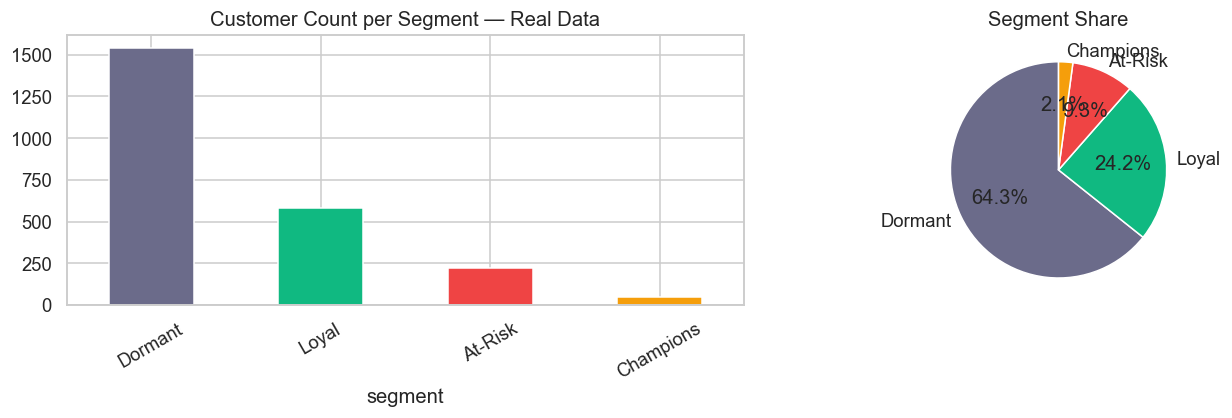

Chart 08 saved.


In [7]:
COLORS={'Champions':'#f59e0b','Loyal':'#10b981','At-Risk':'#ef4444','Discount-Sensitive':'#a78bfa','Dormant':'#6b6b8a'}
sc=rfm['segment'].value_counts()
fig,axes=plt.subplots(1,2,figsize=(13,4))
sc.plot(kind='bar',ax=axes[0],color=[COLORS[s] for s in sc.index],rot=30)
axes[0].set_title('Customer Count per Segment — Real Data')
axes[1].pie(sc,labels=sc.index,autopct='%1.1f%%',colors=[COLORS[s] for s in sc.index],startangle=90)
axes[1].set_title('Segment Share')
plt.tight_layout(); plt.savefig('chart_08_segments.png',bbox_inches='tight'); plt.show()
print('Chart 08 saved.')

## Segment Profiles & Churn Rates

Segment Profiles:
           recency_days  frequency_180d  monetary_180d  return_rate  neg_pct  sessions_30d  ticket_count  churn_next_60d
segment                                                                                                                 
At-Risk          117.72            2.39        1821.58         0.07     0.51          4.83          1.14            0.64
Champions         17.02            5.45        3981.18         0.07     0.67          8.71          1.90            0.10
Dormant          107.72            0.96         632.66         0.07     0.36          4.85          0.62            0.59
Loyal             27.94            2.63        2154.37         0.07     0.50          7.04          1.05            0.11


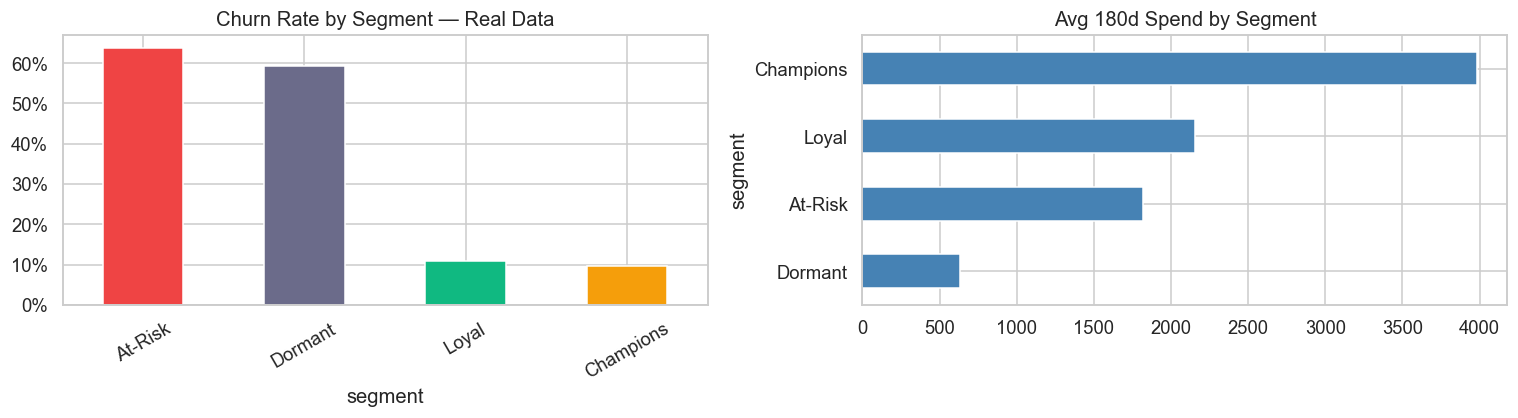


Churn rate per segment:
segment
At-Risk      63.8%
Dormant      59.4%
Loyal        10.8%
Champions     9.8%
Name: churn_next_60d, dtype: object


In [8]:
profile=rfm.groupby('segment')[['recency_days','frequency_180d','monetary_180d','return_rate','neg_pct','sessions_30d','ticket_count','churn_next_60d']].mean().round(2)
print('Segment Profiles:'); print(profile.to_string())
cs=rfm.groupby('segment')['churn_next_60d'].mean().sort_values(ascending=False)
fig,axes=plt.subplots(1,2,figsize=(14,4))
cs.plot(kind='bar',ax=axes[0],color=[COLORS[s] for s in cs.index],rot=30)
axes[0].set_title('Churn Rate by Segment — Real Data'); axes[0].yaxis.set_major_formatter(mt.PercentFormatter(xmax=1))
rfm.groupby('segment')['monetary_180d'].mean().sort_values().plot(kind='barh',ax=axes[1],color='steelblue')
axes[1].set_title('Avg 180d Spend by Segment')
plt.tight_layout(); plt.savefig('chart_09_seg_churn.png',bbox_inches='tight'); plt.show()
print('\nChurn rate per segment:'); print(cs.apply(lambda x:f'{x:.1%}'))

## Budget Prioritization

Priority by Revenue at Risk:
 priority   segment  count   avg_spend  churn_rate  revenue_at_risk
        1   Dormant   1543  632.659546    0.593649         579516.0
        2   At-Risk    224 1821.575268    0.638393         260485.0
        3     Loyal    582 2154.366649    0.108247         135725.0
        4 Champions     51 3981.175294    0.098039          19906.0


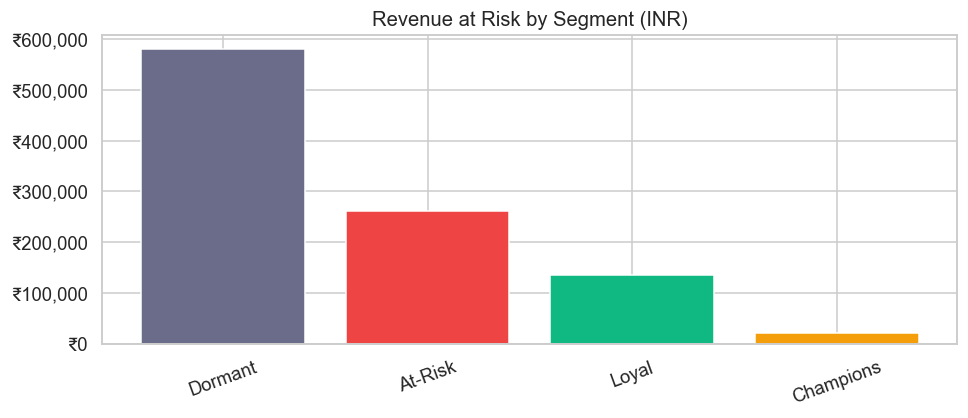

In [9]:
bd=rfm.groupby('segment').agg(count=('customer_id','count'),avg_spend=('monetary_180d','mean'),churn_rate=('churn_next_60d','mean')).reset_index()
bd['revenue_at_risk']=(bd['count']*bd['avg_spend']*bd['churn_rate']).round(0)
bd=bd.sort_values('revenue_at_risk',ascending=False); bd['priority']=range(1,len(bd)+1)
print('Priority by Revenue at Risk:'); print(bd[['priority','segment','count','avg_spend','churn_rate','revenue_at_risk']].to_string(index=False))
fig,ax=plt.subplots(figsize=(9,4))
ax.bar(bd['segment'],bd['revenue_at_risk'],color=[COLORS[s] for s in bd['segment']])
ax.set_title('Revenue at Risk by Segment (INR)'); ax.set_xticklabels(bd['segment'],rotation=20)
ax.yaxis.set_major_formatter(mt.FuncFormatter(lambda x,_:f'₹{x:,.0f}'))
plt.tight_layout(); plt.savefig('chart_10_budget.png',bbox_inches='tight'); plt.show()

## Save segments.csv

In [10]:
out_cols=['customer_id','R','F','M','RFM_score','segment','recency_days','frequency_180d','monetary_180d',
    'return_rate','avg_discount_pct','ticket_count','neg_pct','sessions_30d','last_visit_days_ago',
    'loyalty_tier','last_campaign_received','manual_priority_bucket','churn_next_60d']
rfm[out_cols].to_csv('segments.csv',index=False)
print(f'segments.csv saved — {len(rfm)} customers'); print(rfm['segment'].value_counts())

segments.csv saved — 2400 customers
segment
Dormant      1543
Loyal         582
At-Risk       224
Champions      51
Name: count, dtype: int64


## Manual Review — 10 Ambiguous Cases

In [11]:
amb=rfm[(rfm['RFM_score'].between(7,9))&((rfm['ticket_count']>=1)|(rfm['return_rate']>0.2))].sample(10,random_state=42)
show_cols=['customer_id','segment','R','F','M','RFM_score','recency_days','frequency_180d','monetary_180d','return_rate','ticket_count','sessions_30d','loyalty_tier','churn_next_60d']
print('10 Ambiguous Customer Cases (real customer IDs):')
print(amb[show_cols].reset_index(drop=True).to_string())
amb[show_cols].reset_index(drop=True).to_csv('manual_review_raw.csv',index=False)

10 Ambiguous Customer Cases (real customer IDs):
  customer_id  segment  R  F  M  RFM_score  recency_days  frequency_180d  monetary_180d  return_rate  ticket_count  sessions_30d loyalty_tier  churn_next_60d
0   CUST00871  At-Risk  2  2  4          8           122             3.0        1703.85     0.000000           2.0             3         None               1
1   CUST01844  At-Risk  2  2  5          9           125             2.0        1933.86     0.000000           1.0             8       Silver               0
2   CUST01005  Dormant  2  1  4          7           144             1.0        1329.67     0.000000           1.0             4         None               1
3   CUST02103  Dormant  4  2  3          9            44             2.0        1052.31     0.000000           1.0             0     Platinum               1
4   CUST02384  Dormant  3  2  4          9            68             2.0        1501.14     0.333333           1.0             7       Silver               0
5  

*End of Part 2 — RFM Segmentation*